In [1]:
import torch
from sympy.physics.units import length
from torch import nn
from d2l import torch as d2l
from torchvision.transforms.v2.functional import to_tensor

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

In [2]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [4]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

In [5]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [12]:
#@save
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

training on cuda:0
loss 0.461, train acc 0.828, test acc 0.788
114778.2 examples/sec on cuda:0


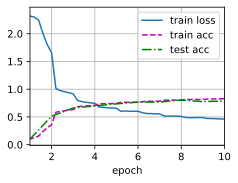

In [13]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

In [31]:
test=next(iter(test_iter))

In [32]:
x,y=test

In [33]:
x.shape

torch.Size([256, 1, 28, 28])

In [46]:
import torch.nn.functional as F

In [54]:
F.softmax(net(x[:11,:,:,:].to('cuda')),dim=1).sort(descending=True)

torch.return_types.sort(
values=tensor([[6.6901e-01, 3.0536e-01, 2.5017e-02, 5.4595e-04, 6.2858e-05, 3.6160e-06,
         2.8458e-06, 2.8183e-06, 1.5429e-06, 9.3811e-07],
        [9.8267e-01, 1.3955e-02, 2.2758e-03, 8.1647e-04, 1.5125e-04, 7.8979e-05,
         4.7571e-05, 2.7842e-06, 1.8600e-06, 1.1971e-08],
        [9.9789e-01, 1.1036e-03, 4.2644e-04, 2.9645e-04, 2.0008e-04, 6.3952e-05,
         9.8669e-06, 2.9304e-06, 1.6007e-06, 4.8443e-07],
        [9.9964e-01, 2.1497e-04, 8.4819e-05, 3.9187e-05, 1.1169e-05, 4.0331e-06,
         1.0711e-06, 1.0368e-06, 2.7626e-07, 6.8324e-08],
        [5.9923e-01, 3.1964e-01, 3.6911e-02, 2.3328e-02, 1.7187e-02, 2.8648e-03,
         7.5364e-04, 7.1945e-05, 1.3046e-05, 7.9016e-07],
        [9.9135e-01, 5.1284e-03, 1.6087e-03, 1.0287e-03, 5.2604e-04, 3.4082e-04,
         9.0087e-06, 4.3066e-06, 3.8780e-06, 7.8812e-07],
        [5.9455e-01, 2.6825e-01, 1.1684e-01, 1.3271e-02, 3.3724e-03, 2.9789e-03,
         4.5128e-04, 2.8657e-04, 1.8506e-06, 9.9585e-

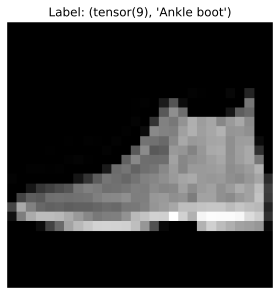

In [52]:
import matplotlib.pyplot as plt

# Fashion-MNIST 的类别映射
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
label=y[0]
img=x[0]
img=img.squeeze()
plt.imshow(img, cmap='gray')
plt.title(f'Label: {label,classes[label.item()]}')  # 注意：label是张量，用 .item() 取数字
plt.axis('off')  # 去掉坐标轴
plt.show()

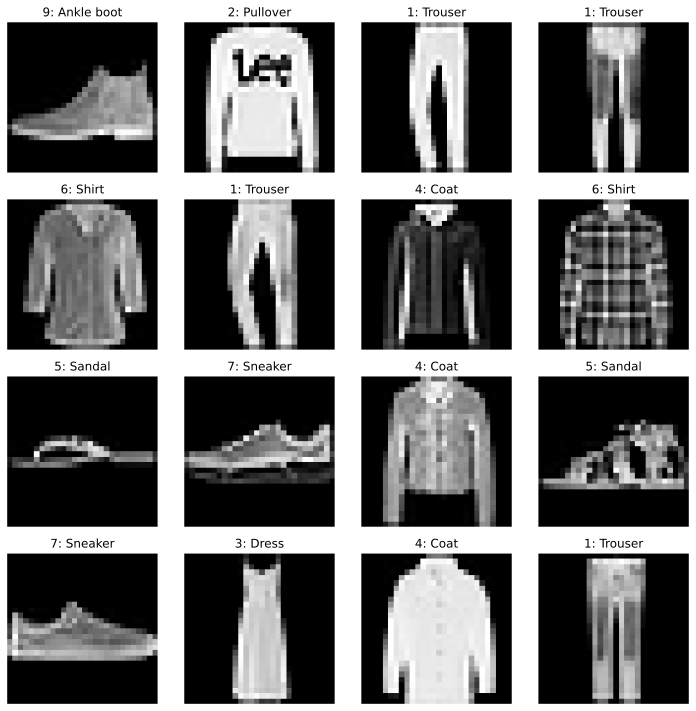

In [55]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()
for i in range(16):
    img = x[i].squeeze()  # 移去通道维度
    ax = axes[i]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{y[i].item()}: {classes[y[i].item()]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [57]:
torch.save(net.state_dict,"lenet_on_fashion_mnist.params")